In [2]:
import pandas as pd
df = pd.read_csv("titanic.csv")

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.shape

(891, 15)

In [5]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

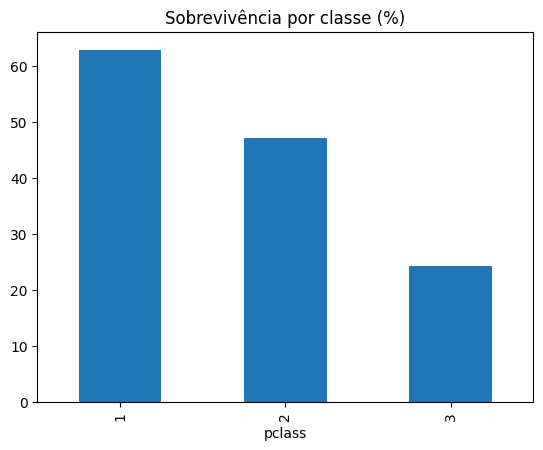

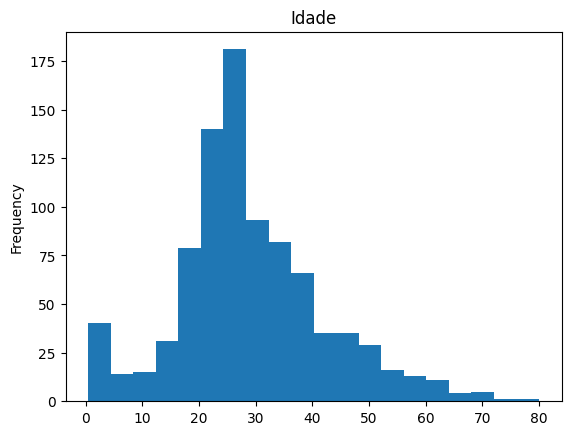

pclass,1,2,3
who,,,
child,83.333333,100.000000,43.103448
man,35.294118,8.080808,11.912226
woman,97.802198,90.909091,49.122807


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("titanic.csv")

# A1 — 891 linhas, 15 colunas
df.shape
df.isna().sum()[lambda s: s > 0]
# age 177 · embarked 2 · embark_town 2 · deck 688
# deck tem 77% de nulos: dá para descartar ou usar só como "tem/não tem"

# A2 — 38,4% sobreviveram
df["survived"].mean() * 100

# A3 — mediana por classe e sexo (1ª classe/homem: 40 anos; 3ª/mulher: 21,5)
df["age"] = df["age"].fillna(df.groupby(["pclass", "sex"])["age"].transform("median"))

# A4 — o porto mais comum é S (Southampton)
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["embark_town"] = df["embark_town"].fillna("Southampton")

# A5
df["faixa_etaria"] = pd.cut(df["age"], bins=[0, 12, 17, 59, 120],
                            labels=["Criança", "Adolescente", "Adulto", "Idoso"])
df["familia"] = df["sibsp"] + df["parch"] + 1

# A6 — mulheres 74,2% x homens 18,9% · 1ª classe 63,0% · 2ª 47,3% · 3ª 24,2%
df.groupby("sex")["survived"].mean() * 100
df.groupby("pclass")["survived"].mean() * 100

# A7
df.pivot_table(index="sex", columns="pclass", values="survived", aggfunc="mean") * 100

# A8 — Criança 58,0% · Adolescente 47,7% · Adulto 36,4% · Idoso 26,9%
df.groupby("faixa_etaria", observed=True)["survived"].mean() * 100
df["sozinho"] = np.where(df["familia"] == 1, "sozinho", "acompanhado")
df.groupby("sozinho")["survived"].mean() * 100   # acompanhado 50,6% · sozinho 30,4%

# A9 — 1ª: 84,15 · 2ª: 20,66 · 3ª: 13,68 · 15 pessoas pagaram 0 (5 na 1ª, 6 na 2ª, 4 na 3ª)
df.groupby("pclass")["fare"].mean()
df.loc[df["fare"] == 0, "pclass"].value_counts()

# A10 — Cherbourg 55,4% · Queenstown 39,0% · Southampton 33,7%
df.groupby("embark_town")["survived"].mean() * 100
pd.crosstab(df["embark_town"], df["pclass"], normalize="index") * 100
# Cherbourg: 50,6% eram da 1ª classe; Queenstown: 93,5% da 3ª

# A11
(df.groupby("pclass")["survived"].mean() * 100).plot(kind="bar", title="Sobrevivência por classe (%)")
plt.show()
df["age"].plot(kind="hist", bins=20, title="Idade")
plt.show()

# A12 — apoio para a conclusão
df.pivot_table(index="who", columns="pclass", values="survived", aggfunc="mean") * 100


In [9]:
df2 = df.groupby("sex")
df2.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False
